**Q) What is Sentiment Analysis?**

- Sentiment Analysis is a Natural Language Processing (NLP) technique used to determine the emotional tone of a text.
- It analyzes whether the text expresses a positive, negative, or neutral sentiment.
-  This technique is widely used to analyze opinions in reviews, social media posts, and customer feedback.
-  Machine learning and deep learning models are commonly used to perform sentiment classification.

**Q) What is Twitter Sentiment Analysis?**

- Twitter Sentiment Analysis is a Natural Language Processing (NLP) technique used to determine the emotional tone (positive, negative, or neutral) expressed in tweets.

- It analyzes the text content of tweets to understand people's opinions, feelings, or attitudes toward a topic, product, or event.

- The process uses machine learning or deep learning models to classify the sentiment of tweets automatically.

-  It can be done for individual tweets or a larger dataset related to a particular topic or event.

**Q) Why is Twitter Sentiment Analysis Important?**

- **Understanding Customer Feedback:** By analyzing the sentiment of customer feedback, companies can identify areas where they need to improve their products or services.

- **Reputation Management:** Sentiment analysis can help companies monitor their brand reputation online and quickly respond to negative comments or reviews.

- **Political Analysis:** Sentiment analysis can help political campaigns understand public opinion and tailor their messaging accordingly.

- **Crisis Management:** In the event of a crisis, sentiment analysis can help organizations monitor social media and news outlets for negative sentiment and respond appropriately.

- **Marketing Research:** Sentiment analysis can help marketers understand consumer behavior and preferences, and develop targeted advertising campaigns.


**Q) How to Do Twitter Sentiment Analysis Using a Dataset?**

- First, collect or download a dataset such as the Sentiment140 Twitter dataset.

- Load the dataset using Python libraries like Pandas.

- Perform data preprocessing including removing URLs, special characters, stopwords, and applying stemming or lemmatization.

- Convert text data into numerical form using TF-IDF, Bag of Words, or word embeddings.

- Split the dataset into training and testing sets.

- Train a machine learning model such as Logistic Regression, Naive Bayes, or SVM.

- Evaluate the model using metrics like accuracy, precision, recall, and F1-score.

- Finally, use the trained model to predict the sentiment of new tweets.

**Twitter Sentiment Analysis Project Pipeline:**

- Import Necessary Dependencies
- Read and Load the Dataset
- Exploratory Data Analysis
- Data Visualization of Target Variables
- Data Preprocessing
- Splitting our data into Train and Test sets.
- Transforming Dataset using TF-IDF Vectorizer
- Function for Model Evaluation
- Model Building
- Model Evaluation

### Step-1: Import the Necessary Dependencies

In [39]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud
from nltk.stem import WordNetLemmatizer

from sklearn.svm import LinearSVC
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix,classification_report

### Step-2: Read and Load the Dataset

In [40]:
DATASET_COLUMNS=['target','ids','date','flag','user','text']
df=pd.read_csv(r"twitter_data.csv",encoding="ISO-8859-1",names=DATASET_COLUMNS)
df.sample(5)

,target,ids,date,flag,user,text
797580,0,2328219257,Thu Jun 25 09:18:50 PDT 2009,NO_QUERY,Lupina78,Finally we had some sunshine again..still my t...
425649,0,2063368714,Sun Jun 07 02:22:46 PDT 2009,NO_QUERY,Prisrizzle,almost 3am. cant sleep. i need a job.
1587233,4,2190911808,Tue Jun 16 04:03:31 PDT 2009,NO_QUERY,Stephanvs,"@dvdstelt Lol, put it online, and I'll also ru..."
828180,4,1556972951,Sun Apr 19 01:18:26 PDT 2009,NO_QUERY,chrishealy,@kathrynbunghole no problem!
227959,0,1978165392,Sat May 30 22:36:19 PDT 2009,NO_QUERY,TylrJoseph,@ddlovato Didn't I warn you? Is it not a goo...


### Step-3: Exploratory Data Analysis

In [6]:
df.columns

Index(['target', 'ids', 'date', 'flag', 'user', 'text'], dtype='object')

In [7]:
len(df)

1600000

In [8]:
df.shape

(1600000, 6)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   target  1600000 non-null  int64 
 1   ids     1600000 non-null  int64 
 2   date    1600000 non-null  object
 3   flag    1600000 non-null  object
 4   user    1600000 non-null  object
 5   text    1600000 non-null  object
dtypes: int64(2), object(4)
memory usage: 73.2+ MB


In [10]:
np.sum(df.isnull().any(axis=1))

np.int64(0)

In [11]:
print('Count of columns in the data is:  ', len(df.columns))
print('Count of rows in the data is:  ', len(df))

Count of columns in the data is:   6
Count of rows in the data is:   1600000


In [12]:
df['target'].unique()

array([0, 4])

In [13]:
df['target'].nunique()

2

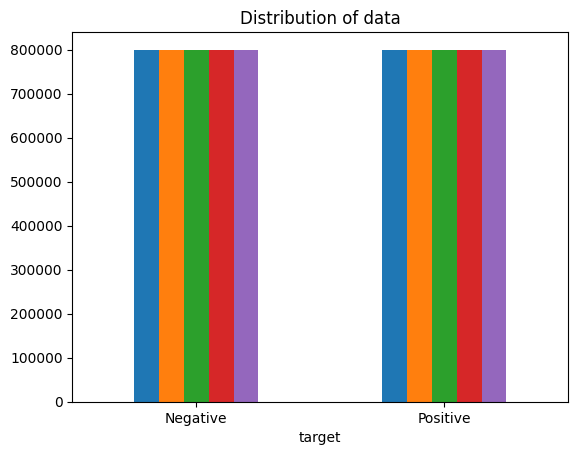

In [14]:
# Plotting the distribution for dataset.
ax = df.groupby('target').count().plot(kind='bar', title='Distribution of data',legend=False)
ax.set_xticklabels(['Negative','Positive'], rotation=0)
# Storing data in lists.
text, sentiment = list(df['text']), list(df['target'])

<Axes: xlabel='target', ylabel='count'>

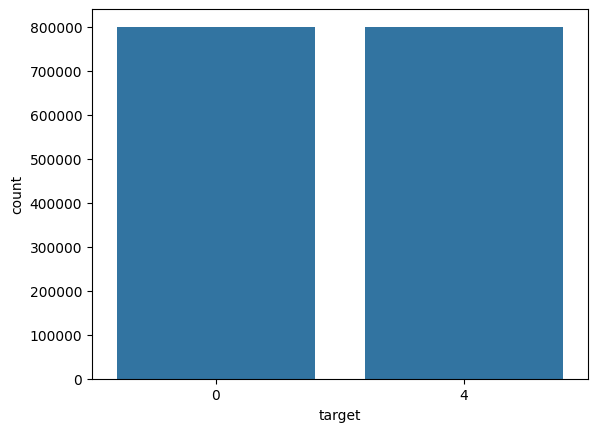

In [15]:
sns.countplot(x='target', data=df)

### Step-5: Data Preprocessing

In the above-given problem statement, before training the model, we performed various pre-processing steps on the dataset that mainly dealt with removing stopwords, removing special characters like emojis, hashtags, etc. The text document is then converted into lowercase for better generalization.

Subsequently, the punctuations were cleaned and removed, thereby reducing the unnecessary noise from the dataset. After that, we also removed the repeating characters from the words along with removing the URLs as they do not have any significant importance.

At last, we then performed Stemming(reducing the words to their derived stems) and Lemmatization(reducing the derived words to their root form, known as lemma) for better results.

In [16]:
# Selecting the text and Target column for our further analysis

data=df[['text','target']]

In [17]:
# Replacing the values to ease understanding. (Assigning 1 to Positive sentiment 4)
data['target']=data['target'].replace(4,1)

C:\Users\swain\AppData\Local\Temp\ipykernel_30320\3449457513.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['target']=data['target'].replace(4,1)


In [18]:
# Printing unique values of target variables

data['target'].unique()

array([0, 1])

In [19]:
# Separating positive and negative tweets

data_pos=data[data['target']==1]
data_neg=data[data['target']==0]

In [20]:
# Taking one-fourth of the data so we can run it on our machine easily

data_pos=data_pos.iloc[:int(20000)]
data_neg=data_neg.iloc[:int(20000)]

In [21]:
# Combining positive and negative tweets

dataset = pd.concat([data_pos, data_neg])

In [38]:
 # Making statement text in lowercase

dataset['text']=dataset['text'].str.lower()
dataset['text'].tail()

19995   NaN
19996   NaN
19997   NaN
19998   NaN
19999   NaN
Name: text, dtype: float64

In [23]:
# Defining set containing all stopwords in English.

stopwordlist = ['a', 'about', 'above', 'after', 'again', 'ain', 'all', 'am', 'an',
             'and','any','are', 'as', 'at', 'be', 'because', 'been', 'before',
             'being', 'below', 'between','both', 'by', 'can', 'd', 'did', 'do',
             'does', 'doing', 'down', 'during', 'each','few', 'for', 'from',
             'further', 'had', 'has', 'have', 'having', 'he', 'her', 'here',
             'hers', 'herself', 'him', 'himself', 'his', 'how', 'i', 'if', 'in',
             'into','is', 'it', 'its', 'itself', 'just', 'll', 'm', 'ma',
             'me', 'more', 'most','my', 'myself', 'now', 'o', 'of', 'on', 'once',
             'only', 'or', 'other', 'our', 'ours','ourselves', 'out', 'own', 're','s', 'same', 'she', "shes", 'should', "shouldve",'so', 'some', 'such',
             't', 'than', 'that', "thatll", 'the', 'their', 'theirs', 'them',
             'themselves', 'then', 'there', 'these', 'they', 'this', 'those',
             'through', 'to', 'too','under', 'until', 'up', 've', 'very', 'was',
             'we', 'were', 'what', 'when', 'where','which','while', 'who', 'whom',
             'why', 'will', 'with', 'won', 'y', 'you', "youd","youll", "youre",
             "youve", 'your', 'yours', 'yourself', 'yourselves']

In [24]:
# Cleaning and removing the above stop words list from the tweet text

STOPWORDS = set(stopwordlist)
def cleaning_stopwords(text):
    return " ".join([word for word in str(text).split() if word not in STOPWORDS])
dataset['text'] = dataset['text'].apply(lambda text: cleaning_stopwords(text))
dataset['text'].head()

800000                love @health4uandpets u guys r best!!
800001    im meeting one besties tonight! cant wait!! - ...
800002    @darealsunisakim thanks twitter add, sunisa! g...
800003    sick really cheap hurts much eat real food plu...
800004                      @lovesbrooklyn2 effect everyone
Name: text, dtype: object

In [25]:
# Cleaning and removing punctuations

import string
english_punctuations = string.punctuation
punctuations_list = english_punctuations
def cleaning_punctuations(text):
    translator = str.maketrans('', '', punctuations_list)
    return text.translate(translator)
dataset['text']= dataset['text'].apply(lambda x: cleaning_punctuations(x))
dataset['text'].tail()

19995    not much time off weekend work trip malmï¿½ fr...
19996                                     one day holidays
19997                     feeling right  hate damn humprey
19998    geezi hv read whole book personality types emb...
19999    threw sign donnie bent over get but thingee ma...
Name: text, dtype: object

In [26]:
# Cleaning and removing repeating characters

def cleaning_repeating_char(text):
    return re.sub(r'(.)1+',r'1',text)
dataset['text']=dataset['text'].apply(lambda x:cleaning_repeating_char(x))
dataset['text'].tail()

19995    not much time off weekend work trip malmï¿½ fr...
19996                                     one day holidays
19997                     feeling right  hate damn humprey
19998    geezi hv read whole book personality types emb...
19999    threw sign donnie bent over get but thingee ma...
Name: text, dtype: object

In [27]:
# Cleaning and removing URLs

def cleaning_URLs(data):
    return re.sub('((www.[^s]+)|(https?://[^s]+))',' ',data)
dataset['text']=dataset['text'].apply(lambda x:cleaning_URLs((x)))
dataset['text'].tail()

19995    not much time off weekend work trip malmï¿½ fr...
19996                                     one day holidays
19997                     feeling right  hate damn humprey
19998    geezi hv read whole book personality types emb...
19999    threw sign donnie bent over get but thingee ma...
Name: text, dtype: object

In [28]:
# Cleaning and removing numeric numbers

def cleaning_numbers(data):
    return re.sub('[0-9]+','',data)
dataset['text']=dataset['text'].apply(lambda x:cleaning_numbers(x))
dataset['text'].tail()

19995    not much time off weekend work trip malmï¿½ fr...
19996                                     one day holidays
19997                     feeling right  hate damn humprey
19998    geezi hv read whole book personality types emb...
19999    threw sign donnie bent over get but thingee ma...
Name: text, dtype: object

In [29]:
# Getting tokenization of tweet text

from nltk.tokenize import RegexpTokenizer
tokenizer = RegexpTokenizer(r'w+')
dataset['text'] = dataset['text'].apply(tokenizer.tokenize)
dataset['text'].head()

800000           []
800001          [w]
800002    [w, w, w]
800003           []
800004           []
Name: text, dtype: object

In [30]:
# Applying stemming

import nltk
st = nltk.PorterStemmer()
def stemming_on_text(data):
    text = [st.stem(word) for word in data]
    return data
dataset['text']= dataset['text'].apply(lambda x: stemming_on_text(x))
dataset['text'].head()

800000           []
800001          [w]
800002    [w, w, w]
800003           []
800004           []
Name: text, dtype: object

In [31]:
 # Applying lemmatizer

lm = nltk.WordNetLemmatizer()
def lemmatizer_on_text(data):
    text = [lm.lemmatize(word) for word in data]
    return data
dataset['text'] = dataset['text'].apply(lambda x: lemmatizer_on_text(x))
dataset['text'].head()

800000           []
800001          [w]
800002    [w, w, w]
800003           []
800004           []
Name: text, dtype: object

In [32]:
# Separating input feature and label

X=data.text
y=data.target

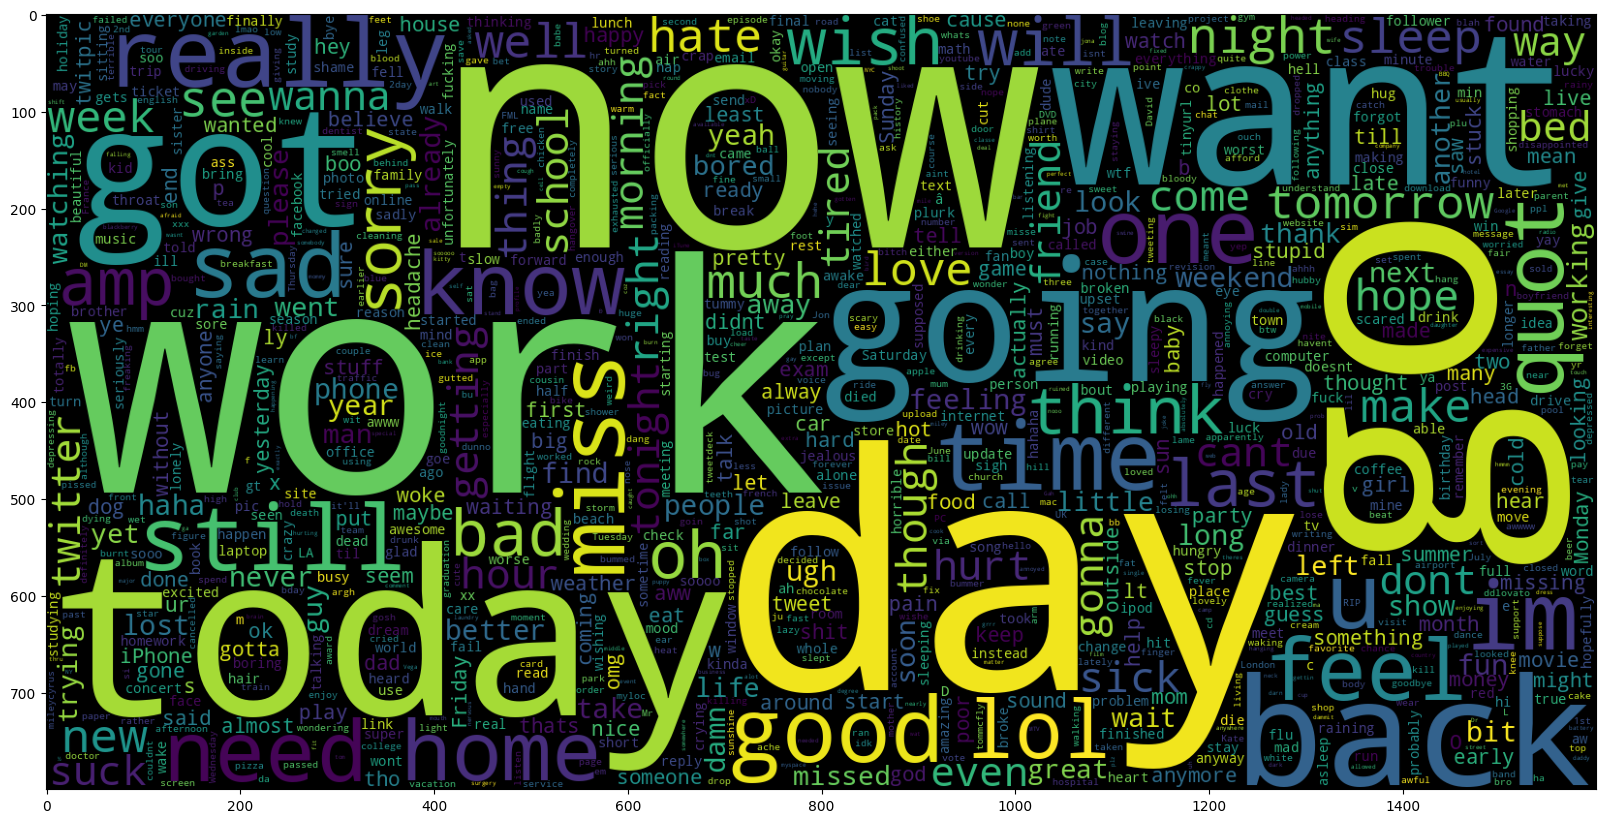

In [33]:
# Plot a cloud of words for negative tweets

data_neg = data['text'][:800000]
plt.figure(figsize = (20,20))
wc = WordCloud(max_words = 1000 , width = 1600 , height = 800,
               collocations=False).generate(" ".join(data_neg))
plt.imshow(wc)

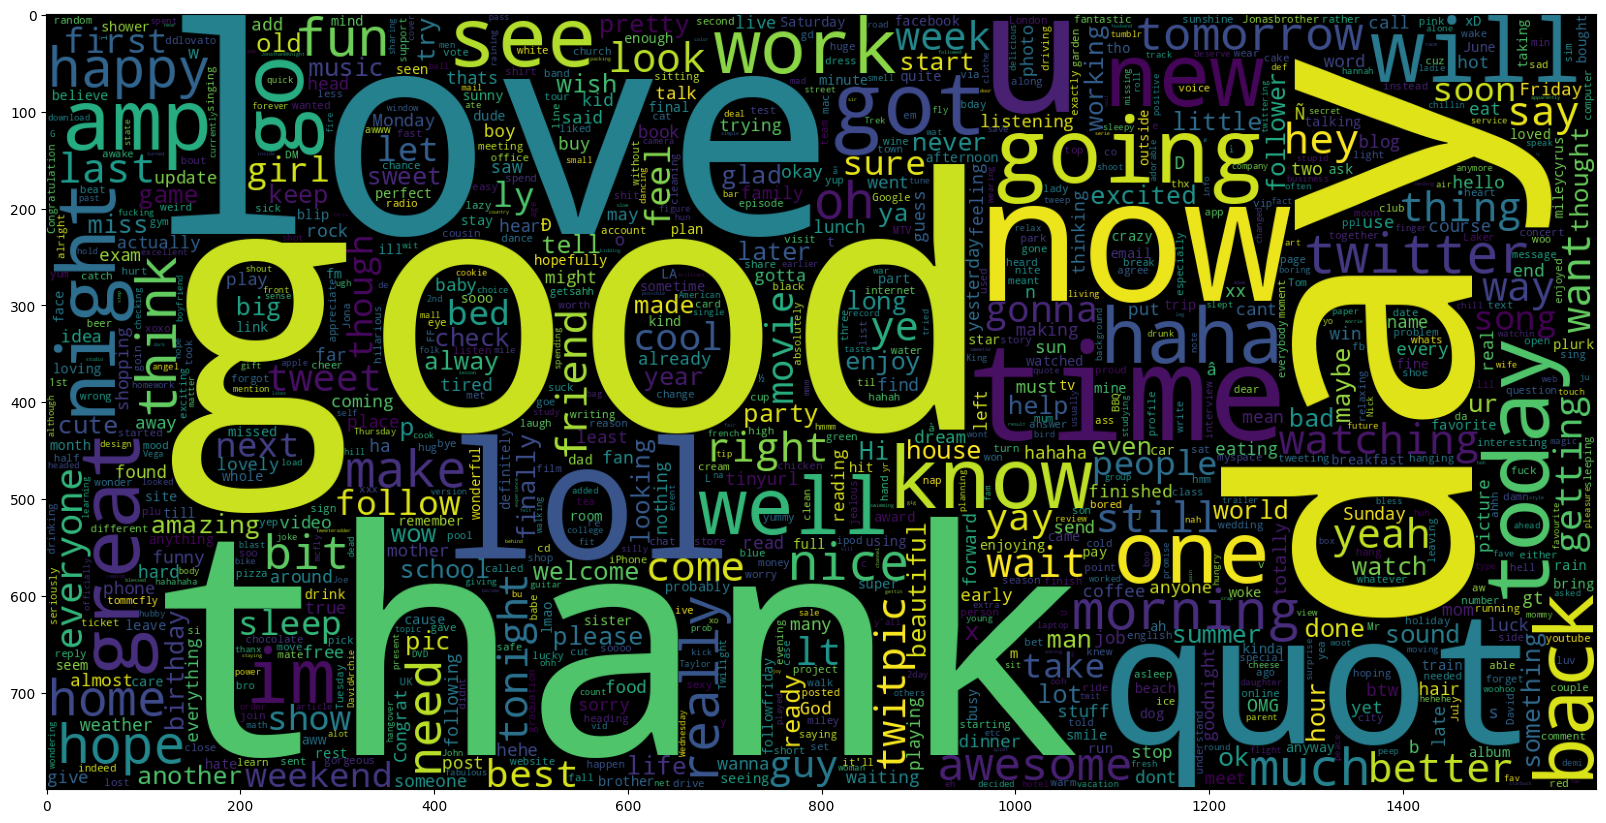

In [34]:
# Plot a cloud of words for positive tweets

data_pos = data['text'][800000:]
wc = WordCloud(max_words = 1000 , width = 1600 , height = 800,
              collocations=False).generate(" ".join(data_pos))
plt.figure(figsize = (20,20))
plt.imshow(wc)

### Step-6: Splitting Our Data Into Train and Test Subsets

In [35]:
# Separating the 95% data for training data and 5% for testing data

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.05, random_state =26105111)

### Step-7: Transforming the Dataset Using TF-IDF Vectorizer

In [36]:
# Fit the TF-IDF Vectorizer

from sklearn.feature_extraction.text import TfidfVectorizer
vectoriser = TfidfVectorizer(ngram_range=(1,2), max_features=500000)
vectoriser.fit(X_train)  
print('No. of feature_words: ', len(vectoriser.get_feature_names_out()))

No. of feature_words:  500000


In [37]:
# Transform the data using TF-IDF Vectorizer

X_train = vectoriser.transform(X_train)
X_test  = vectoriser.transform(X_test)

### Step-8: Function for Model Evaluation

After training the model, we then apply the evaluation measures to check how the model is performing. Accordingly, we use the following evaluation parameters to check the performance of the models respectively:

- Accuracy Score
- Confusion Matrix with Plot
- ROC-AUC Curve

In [35]:
def model_Evaluate(model):
    # Predict values for Test dataset
    y_pred = model.predict(X_test)
    # Print the evaluation metrics for the dataset.
    print(classification_report(y_test, y_pred))
    # Compute and plot the Confusion matrix
    cf_matrix = confusion_matrix(y_test, y_pred)
    categories = ['Negative','Positive']
    group_names = ['True Neg','False Pos', 'False Neg','True Pos']
    group_percentages = ['{0:.2%}'.format(value) for value in cf_matrix.flatten() / np.sum(cf_matrix)]
    labels = [f'{v1}n{v2}' for v1, v2 in zip(group_names,group_percentages)]
    labels = np.asarray(labels).reshape(2,2)
    sns.heatmap(cf_matrix, annot = labels, cmap = 'Blues',fmt = '',
    xticklabels = categories, yticklabels = categories)
    plt.xlabel("Predicted values", fontdict = {'size':14}, labelpad = 10)
    plt.ylabel("Actual values" , fontdict = {'size':14}, labelpad = 10)
    plt.title ("Confusion Matrix", fontdict = {'size':18}, pad = 20)

### Step-9: Model Building

In the problem statement, we have used three different models respectively :

- Bernoulli Naive Bayes Classifier
- SVM (Support Vector Machine)
- Logistic Regression
  
The idea behind choosing these models is that we want to try all the classifiers on the dataset ranging from simple ones to complex models, and then try to find out the one which gives the best performance among them

 ### Model-1

              precision    recall  f1-score   support

           0       0.81      0.79      0.80     40100
           1       0.80      0.81      0.80     39900

    accuracy                           0.80     80000
   macro avg       0.80      0.80      0.80     80000
weighted avg       0.80      0.80      0.80     80000



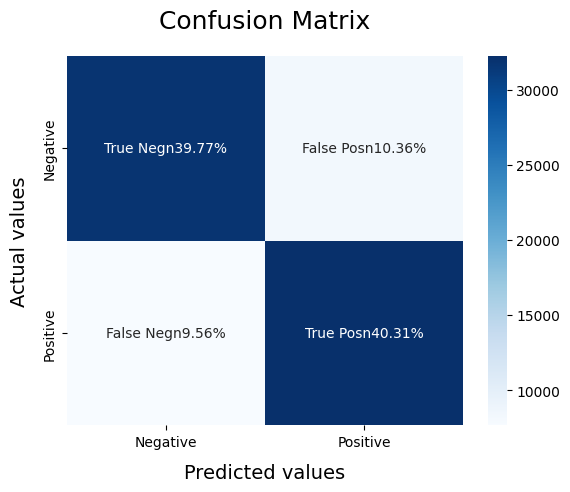

In [36]:
BNBmodel = BernoulliNB()
BNBmodel.fit(X_train, y_train)
model_Evaluate(BNBmodel)
y_pred1 = BNBmodel.predict(X_test)

### Plot the ROC-AUC Curve for model-1

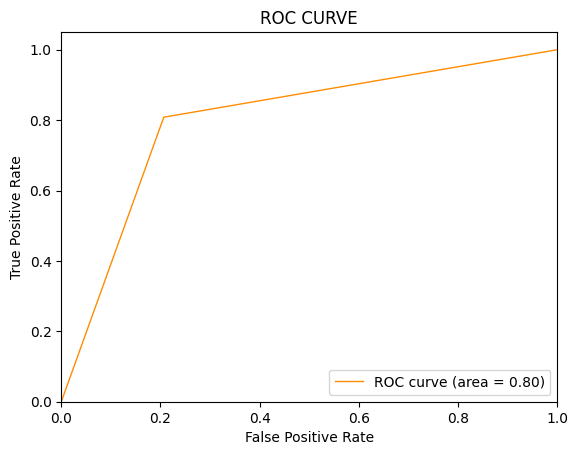

In [37]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_pred1)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=1, label='ROC curve (area = %0.2f)' % roc_auc)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC CURVE')
plt.legend(loc="lower right")
plt.show()

### Model-2:

              precision    recall  f1-score   support

           0       0.82      0.81      0.81     40100
           1       0.81      0.82      0.82     39900

    accuracy                           0.82     80000
   macro avg       0.82      0.82      0.82     80000
weighted avg       0.82      0.82      0.82     80000



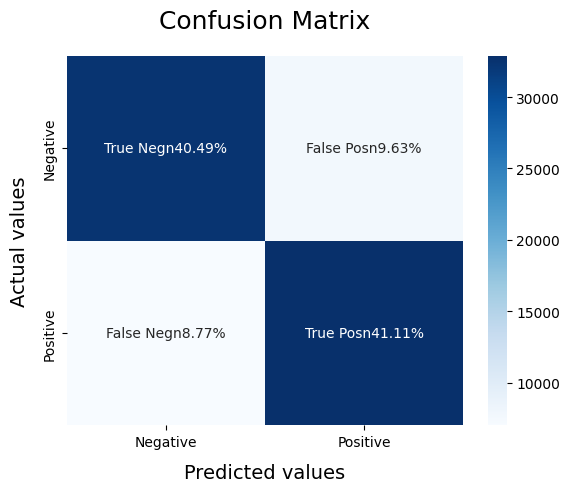

In [38]:
SVCmodel=LinearSVC()
SVCmodel.fit(X_train,y_train)
model_Evaluate(SVCmodel)
y_pred2 =SVCmodel.predict(X_test)

### Model-3

In [3]:
LRmodel=LogisticRegression(C=2,max_iter=1000,n_jobs=-1)
LRmodel.fit(X_train,y_train)
model_Evaluate(LRmodel)
y_pred3 = LRmodel.predict(X_test)

NameError: name 'LogisticRegression' is not defined

### Plot the ROC-AUC Curve for model-3


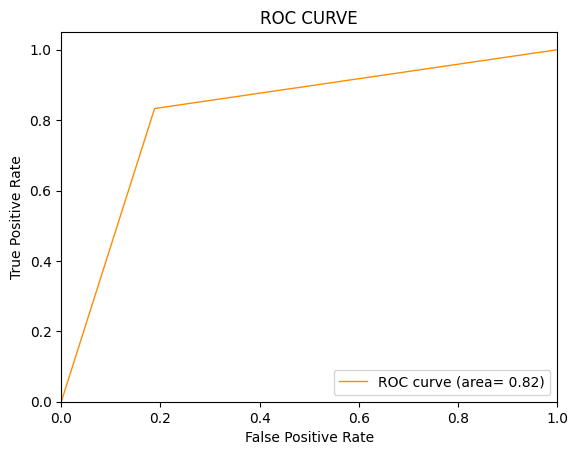

In [40]:
from sklearn.metrics import roc_curve,auc

fpr,tpr,thresholds = roc_curve(y_test,y_pred3)
roc_auc = auc(fpr,tpr)
plt.figure()
plt.plot(fpr,tpr,color='darkorange',lw=1,label='ROC curve (area= %0.2f)' % roc_auc)
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC CURVE')
plt.legend(loc="lower right")
plt.show()

### Step-10: Model Evaluation

Upon evaluating all the models, we can conclude the following details i.e.

**Accuracy:** As far as the accuracy of the model is concerned, Logistic Regression performs better than SVM, which in turn performs better than Bernoulli Naive Bayes.

**F1-score:** The F1 Scores for class 0 and class 1 are :
(a) For class 0: Bernoulli Naive Bayes(accuracy = 0.90) < SVM (accuracy =0.91) < Logistic Regression (accuracy = 0.92)
(b) For class 1: Bernoulli Naive Bayes (accuracy = 0.66) < SVM (accuracy = 0.68) < Logistic Regression (accuracy = 0.69)

**AUC Score:** All three models have the same ROC-AUC score.

We, therefore, conclude that the Logistic Regression is the best model for the above-given dataset.

In our problem statement, Logistic Regression follows the principle of Occam’s Razor, which defines that for a particular problem statement, if the data has no assumption, then the simplest model works the best. Since our dataset does not have any assumptions and Logistic Regression is a simple model. Therefore, the concept holds true for the above-mentioned dataset.


### Step 11 — Hyperparameter Tuning

Improve model performance using GridSearchCV.

In [2]:
from sklearn.model_selection import GridSearchCV

param_grid={
'C':[0.01,0.1,1,10],
'penalty':['l2']
}

grid=GridSearchCV(LogisticRegression(),param_grid,cv=5)
grid.fit(X_train,y_train)

print(grid.best_params_)

NameError: name 'LogisticRegression' is not defined

### Step 12 — Cross Validation

In [1]:
from sklearn.model_selection import cross_val_score

scores=cross_val_score(grid,X_train,y_train,cv=5,max_iter=100)

print(scores.mean())

NameError: name 'grid' is not defined

### Step 13 — Feature Importance

In [ ]:
good
love
happy
bad
hate

### Step 14 — Test With Custom Tweet

In [ ]:
tweet="I love this movie"

vector=vectorizer.transform([tweet])

prediction = grid.predict(vector)
print(prediction)

**Conclusion:**

We hope through this article, you got a basic of how twiiter Sentimental Analysis is used to understand public emotions behind people’s tweets. As you’ve read in this article, Twitter Sentimental Analysis dataset helps us preprocess the data (tweets) using different methods and feed it into ML models to give the best accuracy.

Hope you like the article! Twitter sentiment analysis is a powerful tool for understanding public opinion. A Twitter sentiment analysis project using Python helps analyze tweet sentiment. A quality Twitter sentiment analysis dataset enhances sentiment analysis on Twitter.